<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
data=pd.read_csv("/content/Mall_Customers.csv")

In [4]:
data.head(

)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


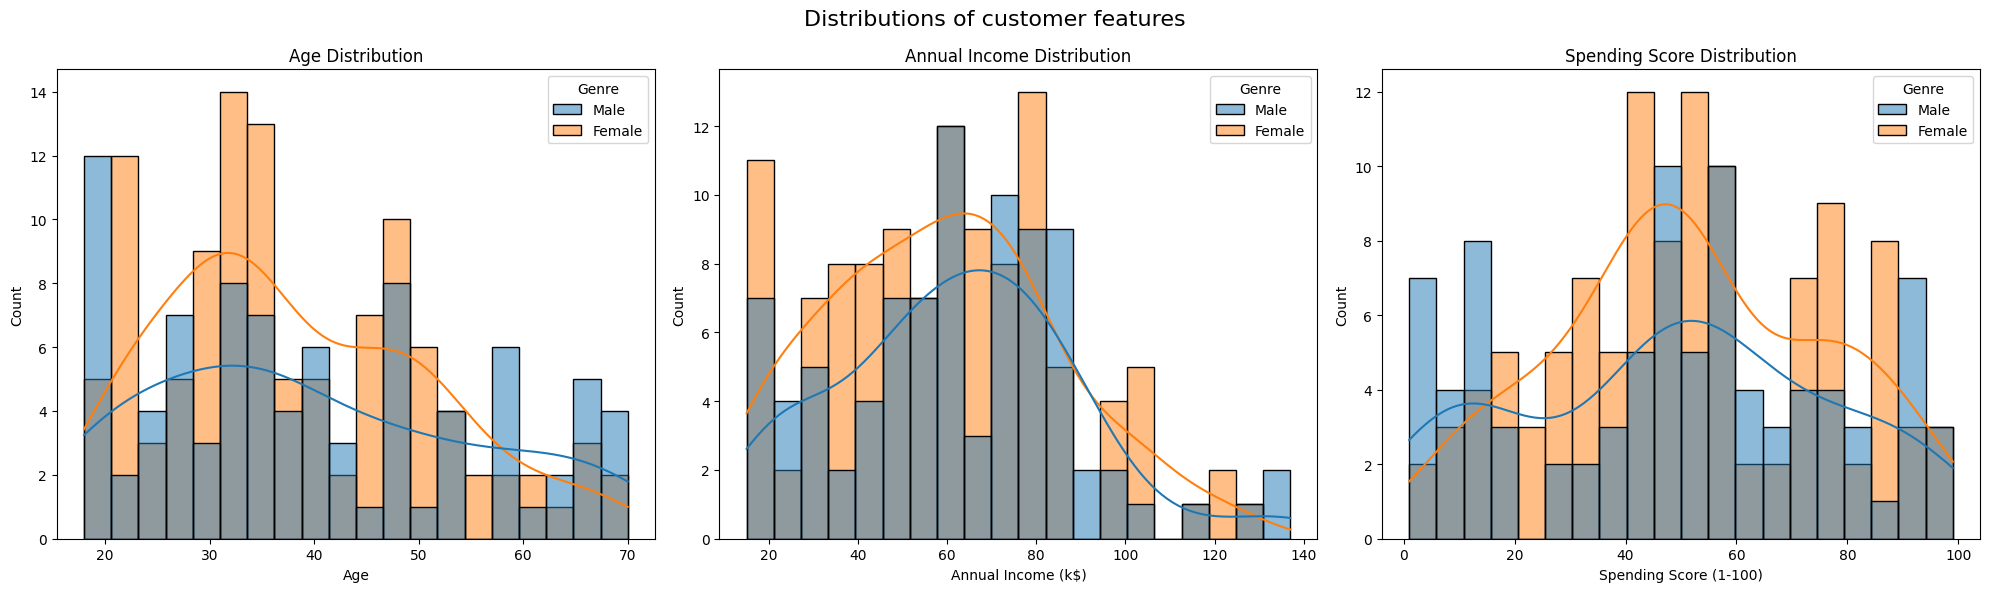

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distributions of customer features', fontsize=16)

sns.histplot(ax=axes[0], data=data, x='Age', kde=True, bins=20, hue='Genre')
axes[0].set_title('Age Distribution')

sns.histplot(ax=axes[1], data=data, x='Annual Income (k$)', kde=True, bins=20, hue='Genre')
axes[1].set_title('Annual Income Distribution')

sns.histplot(ax=axes[2], data=data, x='Spending Score (1-100)', kde=True, bins=20, hue='Genre')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

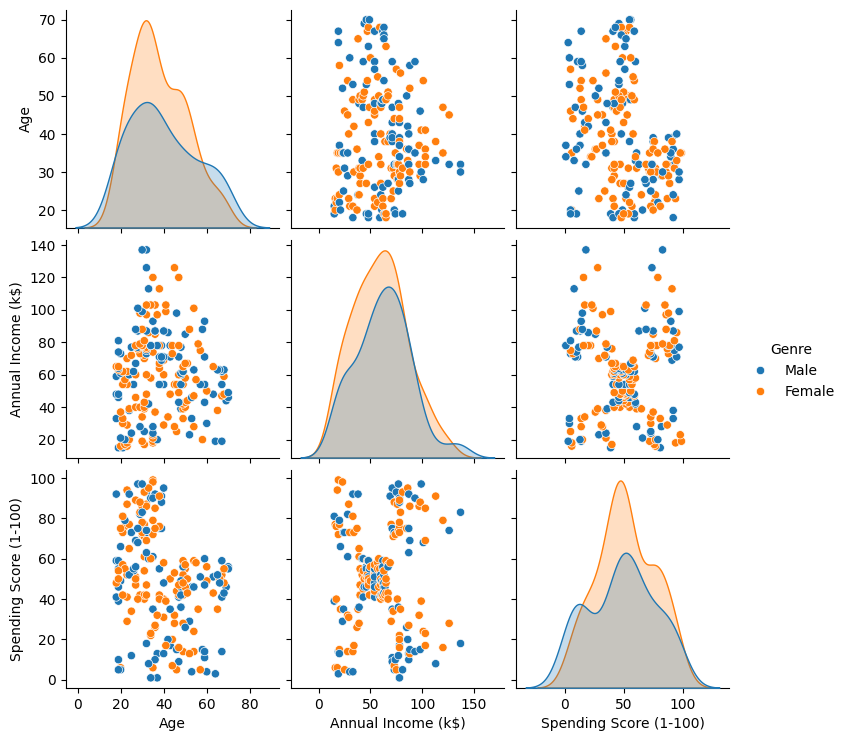

In [6]:
sns.pairplot(
    data,
    vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
    hue='Genre',      # use 'Gender' if that's your column name
    diag_kind='kde'
)

plt.show()

In [7]:
X1 = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)

In [9]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X1_scaled)
    wcss.append(kmeans.inertia_)

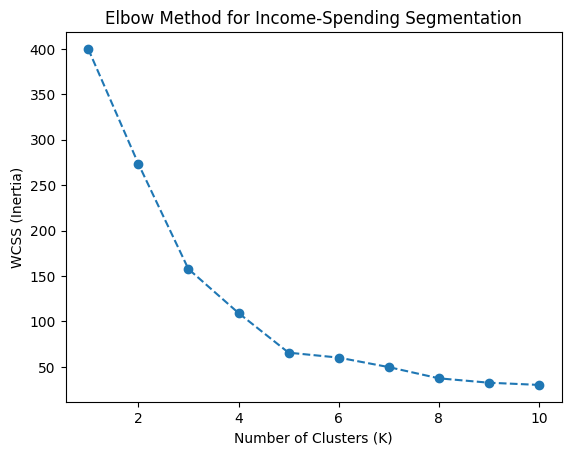

In [10]:
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Income-Spending Segmentation')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, random_state=42)

data['Income Cluster'] = kmeans.fit_predict(X1_scaled)

data

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


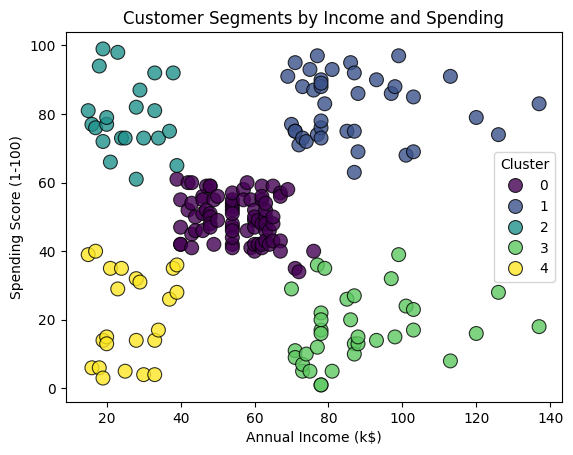

In [12]:
sns.scatterplot(
    data=data,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Income Cluster',
    palette='viridis',
    s=100,
    alpha=0.8,
    edgecolor='black'
)

plt.title('Customer Segments by Income and Spending')
plt.legend(title='Cluster')
plt.show()

In [13]:
data['Income Cluster'].value_counts()

,count
Income Cluster,
0,81
1,39
3,35
4,23
2,22
